# Avance 1 – Análisis Exploratorio de Datos (EDA)

## Contexto
El dataset corresponde al historial transaccional de gastos de viaje de FIRA extraído de SAP.  
Cubre registros desde enero 2018 hasta mayo 2026 (fecha contable).  
La unidad de observación del modelo final será **unidad de primer nivel × partida presupuestal × mes**; el EDA opera al nivel granular de concepto de gasto.

### Preguntas guía del EDA
1. ¿Hay valores faltantes? ¿Se pueden identificar patrones de ausencia?
2. ¿Cuáles son las estadísticas resumidas del conjunto?
3. ¿Hay valores atípicos?
4. ¿Cuál es la cardinalidad de las variables categóricas?
5. ¿Existen distribuciones sesgadas? ¿Se necesita transformación no lineal?
6. ¿Se identifican tendencias temporales?
7. ¿Hay correlación entre variables dependientes e independientes?
8. ¿Cómo se distribuyen los datos por categoría (análisis bivariado)?
9. ¿Hay desequilibrio en las clases de la variable objetivo?

---
## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Paleta institucional FIRA-compatible
PALETTE = ['#1a5276', '#2980b9', '#85c1e9', '#e74c3c', '#e67e22',
           '#2ecc71', '#8e44ad', '#f39c12', '#1abc9c', '#c0392b',
           '#16a085', '#d35400']
sns.set_style('whitegrid')
sns.set_palette(PALETTE)

FIG_DIR = './'  # cambiar si se quiere guardar figuras

print('Librerías cargadas.')

Librerías cargadas.


---
## 1. Carga de datos

In [2]:
# Ajustar la ruta si el archivo está en otra ubicación
DATA_PATH = 'historico_SAP.parquet'

df_raw = pd.read_parquet(DATA_PATH)
print(f'Registros: {len(df_raw):,}')
print(f'Columnas : {df_raw.shape[1]}')
df_raw.head(3)

Registros: 506,149
Columnas : 14


,Clave Empleado,Viaje,Clave Concepto,Concepto,Fecha Contable,Cuenta Contable,Partida Presupuestal,Funcionario o resto de personal,Grupo Tipo Viaje,Clave Centro Costo,Fecha inicio,Fecha Final,Documento Contable,Monto Gasto
0,"9,146.00","3,924.00",132,Cuota sin comprobar,2019-08-02,5302937504,37504,FUNCIONARIO,GC,10000000,2019-07-22,2019-07-23,1280021356,232.00
1,"9,146.00","3,924.00",131,Alimentación-Hospedaje,2019-08-02,5302937504,37504,FUNCIONARIO,GC,10000000,2019-07-22,2019-07-23,1280021356,"1,814.54"
2,"9,146.00","3,924.00",129,Impuestos Alim-Hosp,2019-08-02,5302937504,37504,FUNCIONARIO,GC,10000000,2019-07-22,2019-07-23,1280021356,344.77


---
## 2. Estructura del dataset
### 2.1 Tipos de datos y descripción de columnas

In [3]:
col_desc = {
    'Clave Empleado'              : 'ID numérico del empleado en SAP',
    'Viaje'                       : 'ID del viaje/solicitud en SAP',
    'Clave Concepto'              : 'Código del concepto de gasto (alimentación, gasolina, etc.)',
    'Concepto'                    : 'Descripción del concepto de gasto',
    'Fecha Contable'              : 'Fecha en que Contabilidad autorizó y registró el gasto',
    'Cuenta Contable'             : 'Cuenta contable SAP asociada al gasto',
    'Partida Presupuestal'        : 'Partida presupuestal (8 partidas vigiladas + 32502 Renta de Vehículo)',
    'Funcionario o resto de personal': 'Categoría del empleado: FUNCIONARIO / RESTO DE PERSONAL',
    'Grupo Tipo Viaje'            : 'GC = Gasto Corriente / CAP = Capacitación',
    'Clave Centro Costo'          : 'Centro de costo SAP (231 unidades administrativas)',
    'Fecha inicio'                : 'Fecha de inicio del viaje',
    'Fecha Final'                 : 'Fecha de fin del viaje',
    'Documento Contable'          : 'Número de documento contable SAP',
    'Monto Gasto'                 : 'Monto del concepto en MXN (puede ser negativo = ajuste)',
}

desc_df = pd.DataFrame({
    'Dtype'      : df_raw.dtypes,
    'Descripción': col_desc,
    'Nulos'      : df_raw.isnull().sum(),
    '% Nulos'    : (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'Cardinalidad': df_raw.nunique(),
})
desc_df

,Dtype,Descripción,Nulos,% Nulos,Cardinalidad
Clave Empleado,float64,ID numérico del empleado en SAP,33,0.01,1567
Viaje,float64,ID del viaje/solicitud en SAP,33,0.01,22438
Clave Concepto,int64,"Código del concepto de gasto (alimentación, ga...",0,0.00,22
Concepto,object,Descripción del concepto de gasto,0,0.00,21
Fecha Contable,datetime64[ns],Fecha en que Contabilidad autorizó y registró ...,0,0.00,2251
Cuenta Contable,int64,Cuenta contable SAP asociada al gasto,0,0.00,9
Partida Presupuestal,int64,Partida presupuestal (8 partidas vigiladas + 3...,0,0.00,9
Funcionario o resto de personal,object,Categoría del empleado: FUNCIONARIO / RESTO DE...,0,0.00,2
Grupo Tipo Viaje,object,GC = Gasto Corriente / CAP = Capacitación,33,0.01,2
Clave Centro Costo,int64,Centro de costo SAP (231 unidades administrati...,0,0.00,238


### 2.2 Estadísticas descriptivas

In [4]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Clave Empleado,"506,116.00",NaN,NaN,NaN,"87,694.31","9,146.00","81,512.00","90,517.00","90,847.00","91,473.00","5,138.71"
Viaje,"506,116.00",NaN,NaN,NaN,"5,735.66",2.00,"2,991.75","4,013.00","5,843.00","26,333.00","5,026.71"
Clave Concepto,"506,149.00",NaN,NaN,NaN,129.79,0.00,130.00,132.00,133.00,138.00,10.59
Concepto,506149,21,Cuota sin comprobar,148995,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fecha Contable,506149,NaN,NaN,NaN,2021-09-21 04:11:54.012672256,2018-01-02 00:00:00,2019-03-13 00:00:00,2021-07-29 00:00:00,2024-03-25 00:00:00,2026-05-05 00:00:00,NaN
Cuenta Contable,"506,149.00",NaN,NaN,NaN,"5,302,934,940.69","5,302,232,502.00","5,302,937,201.00","5,302,937,501.00","5,302,937,501.00","5,302,937,504.00","11,334.75"
Partida Presupuestal,"506,149.00",NaN,NaN,NaN,"35,092.82","26,102.00","37,201.00","37,501.00","37,501.00","37,504.00","4,606.60"
Funcionario o resto de personal,506149,2,RESTO DE PERSONAL,472333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Grupo Tipo Viaje,506116,2,GC,485624,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Clave Centro Costo,"506,149.00",NaN,NaN,NaN,"18,168,651.71","10,000,000.00","19,020,100.00","19,030,502.00","19,040,501.00","19,050,602.00","2,220,964.89"


---
## 3. Calidad de datos
### 3.1 Valores faltantes – patrón de ausencia

In [5]:
# Registros con al menos un nulo
mask_null = df_raw.isnull().any(axis=1)
print(f'Registros con al menos un nulo: {mask_null.sum()} ({mask_null.mean()*100:.2f}%)')

# ¿Son los mismos registros los que tienen nulos en Clave Empleado, Viaje y Grupo Tipo Viaje?
nulos = df_raw[mask_null][['Clave Empleado','Viaje','Grupo Tipo Viaje',
                            'Fecha inicio','Fecha Final','Concepto','Monto Gasto']]
print('\nConceptos de registros con nulos:')
print(nulos['Concepto'].value_counts().head(10))

print('\nPartidas de registros con nulos:')
print(df_raw[mask_null]['Partida Presupuestal'].value_counts())

Registros con al menos un nulo: 41 (0.01%)

Conceptos de registros con nulos:
Concepto
MM Avión    41
Name: count, dtype: int64

Partidas de registros con nulos:
Partida Presupuestal
37104    21
37101    20
Name: count, dtype: int64


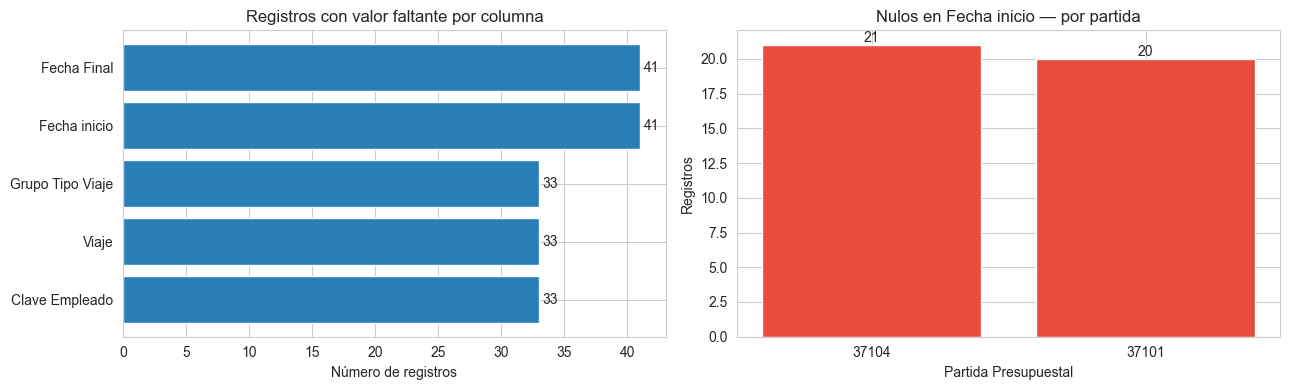


HALLAZGO – Valores faltantes:
El dataset tiene muy pocos nulos (<0.02% del total), todos en partidas de avión
(37101 y 37104), con dos causas de negocio distintas:

1. Nulos en 'Fecha inicio' y 'Fecha Final' (41 registros):
   Comisiones que no se realizaron pero generaron un cargo de pasaje aéreo.
   El vuelo fue cobrado por la agencia aunque el viaje no ocurrió, por lo que
   no existe fecha de comisión que registrar en SAP.
   Estrategia: conservarlos como gasto ejercido (el cargo es real);
   usar Fecha Contable como referencia temporal. No imputar fechas de viaje.

2. Nulos en 'Clave Empleado', 'Viaje' y 'Grupo Tipo Viaje' (33 registros):
   Cargos de avión que SAP no pudo asociar a un viaje ni a un empleado específico.
   El gasto existe contablemente pero sin trazabilidad al nivel de persona o comisión.
   Estrategia: incluirlos en el gasto agregado mensual por partida y centro de costo
   (impactan el presupuesto); excluirlos de análisis que requieran atributos del empleado.



In [6]:
# Análisis de valores faltantes
cols_con_nulos = df_raw.columns[df_raw.isnull().any()].tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Gráfica 1: conteo de nulos por columna
nulos_conteo = df_raw[cols_con_nulos].isnull().sum().sort_values(ascending=True)
axes[0].barh(nulos_conteo.index, nulos_conteo.values, color='#2980b9', edgecolor='white')
axes[0].set_title('Registros con valor faltante por columna')
axes[0].set_xlabel('Número de registros')
for i, v in enumerate(nulos_conteo.values):
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=10)

# Gráfica 2: nulos en Fecha inicio por partida
nulos_partida = df_raw[df_raw['Fecha inicio'].isnull()]['Partida Presupuestal'].value_counts()
axes[1].bar(nulos_partida.index.astype(str), nulos_partida.values, color='#e74c3c', edgecolor='white')
axes[1].set_title('Nulos en Fecha inicio — por partida')
axes[1].set_xlabel('Partida Presupuestal')
axes[1].set_ylabel('Registros')
for i, v in enumerate(nulos_partida.values):
    axes[1].text(i, v + 0.2, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("""
HALLAZGO – Valores faltantes:
El dataset tiene muy pocos nulos (<0.02% del total), todos en partidas de avión
(37101 y 37104), con dos causas de negocio distintas:

1. Nulos en 'Fecha inicio' y 'Fecha Final' (41 registros):
   Comisiones que no se realizaron pero generaron un cargo de pasaje aéreo.
   El vuelo fue cobrado por la agencia aunque el viaje no ocurrió, por lo que
   no existe fecha de comisión que registrar en SAP.
   Estrategia: conservarlos como gasto ejercido (el cargo es real);
   usar Fecha Contable como referencia temporal. No imputar fechas de viaje.

2. Nulos en 'Clave Empleado', 'Viaje' y 'Grupo Tipo Viaje' (33 registros):
   Cargos de avión que SAP no pudo asociar a un viaje ni a un empleado específico.
   El gasto existe contablemente pero sin trazabilidad al nivel de persona o comisión.
   Estrategia: incluirlos en el gasto agregado mensual por partida y centro de costo
   (impactan el presupuesto); excluirlos de análisis que requieran atributos del empleado.

En ambos casos la Fecha Contable está disponible, por lo que ningún registro
queda fuera del análisis temporal ni del cómputo presupuestal.
""")

### 3.2 Montos negativos (ajustes/cancelaciones)

In [7]:
neg = df_raw[df_raw['Monto Gasto'] < 0]
print(f'Registros con monto negativo: {len(neg)} ({len(neg)/len(df_raw)*100:.3f}%)')
print(f'Suma de montos negativos: ${neg["Monto Gasto"].sum():,.2f}')
print(f'\nDistribución por partida:')
print(neg.groupby('Partida Presupuestal')['Monto Gasto'].agg(['count','sum']).rename(
    columns={'count':'n_registros','sum':'suma_mxn'}))
print(f'\nDistribución por concepto (top 10):')
print(neg.groupby('Concepto')['Monto Gasto'].agg(['count','sum']).sort_values('count', ascending=False).head(10))

Registros con monto negativo: 94 (0.019%)
Suma de montos negativos: $-111,944.59

Distribución por partida:
                      n_registros   suma_mxn
Partida Presupuestal                        
26102                           3  -2,357.95
26104                           1  -1,367.40
37201                          23  -8,668.82
37204                           1    -262.00
37501                          62 -94,055.33
37504                           4  -5,233.09

Distribución por concepto (top 10):
                                count        sum
Concepto                                        
Impuestos Alim-Hosp                22  -6,742.10
Alimentación-Hospedaje             18 -79,910.42
Peajes con CFDI                    16  -6,517.02
Cuota sin comprobar                14  -8,624.00
Alimentación sin Pernocta          12  -4,011.90
Gasolina Auto c/financiamiento      4  -3,725.35
Peajes sin CFDI                     4  -1,287.00
Estacionamiento sin CFDI            3    -198.00
Cuota

In [8]:
print("""
HALLAZGO – Montos negativos:
Los 94 registros con monto negativo representan ajustes o reversiones de gastos ya
registrados. Aparecen en todas las partidas. Son contablemente válidos: un gasto que
se revierte o modifica genera un concepto de signo contrario en SAP.

Estrategia (A2 – Feature Engineering):
  - Conservarlos en el cálculo del gasto agregado mensual (se netean correctamente).
  - En análisis univariado y bivariado del EDA se trabaja con el dataset completo.
  - No deben imputarse a cero ni eliminarse; hacerlo sobreestimaría el gasto real.
""")


HALLAZGO – Montos negativos:
Los 94 registros con monto negativo representan ajustes o reversiones de gastos ya
registrados. Aparecen en todas las partidas. Son contablemente válidos: un gasto que
se revierte o modifica genera un concepto de signo contrario en SAP.

Estrategia (A2 – Feature Engineering):
  - Conservarlos en el cálculo del gasto agregado mensual (se netean correctamente).
  - En análisis univariado y bivariado del EDA se trabaja con el dataset completo.
  - No deben imputarse a cero ni eliminarse; hacerlo sobreestimaría el gasto real.



### 3.3 Partida 32502 – Renta de Vehículo (fuera del alcance del modelo)

In [9]:
print('Partidas únicas en el dataset:')
print(df_raw['Partida Presupuestal'].value_counts().to_frame())

print("""
HALLAZGO: La partida 32502 (Renta de Vehículo, 110 registros) no forma parte de las
8 partidas presupuestales vigiladas documentadas en el A0. Se excluirá del dataset de
modelado. Se conserva una copia separada para análisis complementario si el sponsor lo requiere.
""")

# Dataset de trabajo: solo las 8 partidas del modelo
PARTIDAS_MODELO = [26102, 26104, 37101, 37104, 37201, 37204, 37501, 37504]
df = df_raw[df_raw['Partida Presupuestal'].isin(PARTIDAS_MODELO)].copy()
print(f'Dataset de trabajo (8 partidas): {len(df):,} registros')

Partidas únicas en el dataset:
                       count
Partida Presupuestal        
37501                 315182
26102                 101374
37201                  53714
37504                  21828
37204                   7452
26104                   3813
37101                   1953
37104                    723
32502                    110

HALLAZGO: La partida 32502 (Renta de Vehículo, 110 registros) no forma parte de las
8 partidas presupuestales vigiladas documentadas en el A0. Se excluirá del dataset de
modelado. Se conserva una copia separada para análisis complementario si el sponsor lo requiere.

Dataset de trabajo (8 partidas): 506,039 registros


### 3.4 Desfase contable: Fecha Contable vs. Fecha de inicio del viaje

Estadísticas del desfase contable (días entre inicio del viaje y registro contable):
                  count  mean   std     min  25%  50%   75%      max
desfase_dias 505,998.00 11.25 10.92 -340.00 6.00 9.00 14.00 1,454.00


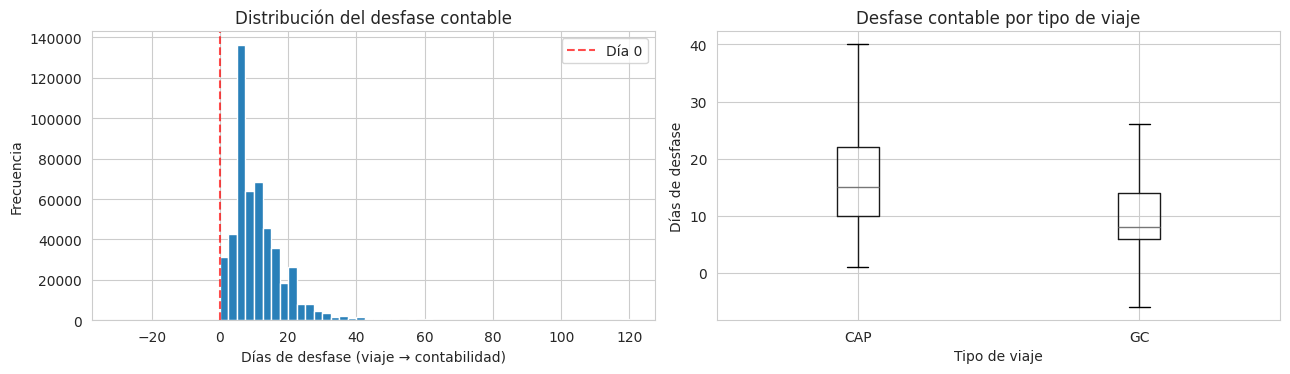


Registros con desfase negativo (contabilidad ANTES del viaje): 23
Desfase mediano: 9 días
Desfase P90: 21 días


In [10]:
df_desfase = df.dropna(subset=['Fecha inicio']).copy()
df_desfase['desfase_dias'] = (df_desfase['Fecha Contable'] - df_desfase['Fecha inicio']).dt.days

print('Estadísticas del desfase contable (días entre inicio del viaje y registro contable):')
print(df_desfase['desfase_dias'].describe().to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma
axes[0].hist(df_desfase['desfase_dias'].clip(-30, 120), bins=60, color='#2980b9', edgecolor='white')
axes[0].set_xlabel('Días de desfase (viaje → contabilidad)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del desfase contable')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7, label='Día 0')
axes[0].legend()

# Por tipo de gasto
df_desfase.boxplot(column='desfase_dias', by='Grupo Tipo Viaje',
                   ax=axes[1], showfliers=False)
axes[1].set_title('Desfase contable por tipo de viaje')
axes[1].set_xlabel('Tipo de viaje')
axes[1].set_ylabel('Días de desfase')
plt.suptitle('')
plt.tight_layout()
plt.show()

desfase_neg = (df_desfase['desfase_dias'] < 0).sum()
print(f'\nRegistros con desfase negativo (contabilidad ANTES del viaje): {desfase_neg}')
print(f'Desfase mediano: {df_desfase["desfase_dias"].median():.0f} días')
print(f'Desfase P90: {df_desfase["desfase_dias"].quantile(0.9):.0f} días')

In [11]:
# Desfase por partida presupuestal
desfase_partida = df_desfase.groupby('Partida Presupuestal')['desfase_dias'].agg(['median','mean','max']).round(1)
desfase_partida.columns = ['Mediana (días)', 'Media (días)', 'Máx (días)']
print('Desfase contable por partida presupuestal:')
print(desfase_partida)

print("""
HALLAZGO – Desfase contable:
El gasto se registra contablemente varios días (y a veces semanas) DESPUÉS del viaje.
La mediana del desfase está alrededor de 7–14 días, con colas hasta >60 días.
Los registros con desfase negativo corresponden principalmente a pasajes aéreos
(proceso batch por agencia externa) donde Fecha inicio puede ser anterior a la
liquidación mensual.

Implicación para el modelo:
  - Se usará FECHA CONTABLE como referencia presupuestal (coincide con cómo FIRA
    reporta el gasto ejercido).
  - El desfase se incorporará como variable en A2 para capturar comprobaciones
    tardías dentro del mismo ejercicio fiscal.
""")

Desfase contable por partida presupuestal:
                      Mediana (días)  Media (días)  Máx (días)
Partida Presupuestal                                          
26102                           8.00          9.90         383
26104                          12.00         14.80         382
37101                          44.00         43.40         795
37104                          40.50         41.50         211
37201                          10.00         12.90        1454
37204                          13.00         16.00         382
37501                           8.00         10.70         835
37504                          12.00         15.10         382

HALLAZGO – Desfase contable:
El gasto se registra contablemente varios días (y a veces semanas) DESPUÉS del viaje.
La mediana del desfase está alrededor de 7–14 días, con colas hasta >60 días.
Los registros con desfase negativo corresponden principalmente a pasajes aéreos
(proceso batch por agencia externa) donde Fecha inici

---
## 4. Análisis Univariado
### 4.1 Variable objetivo: Monto Gasto

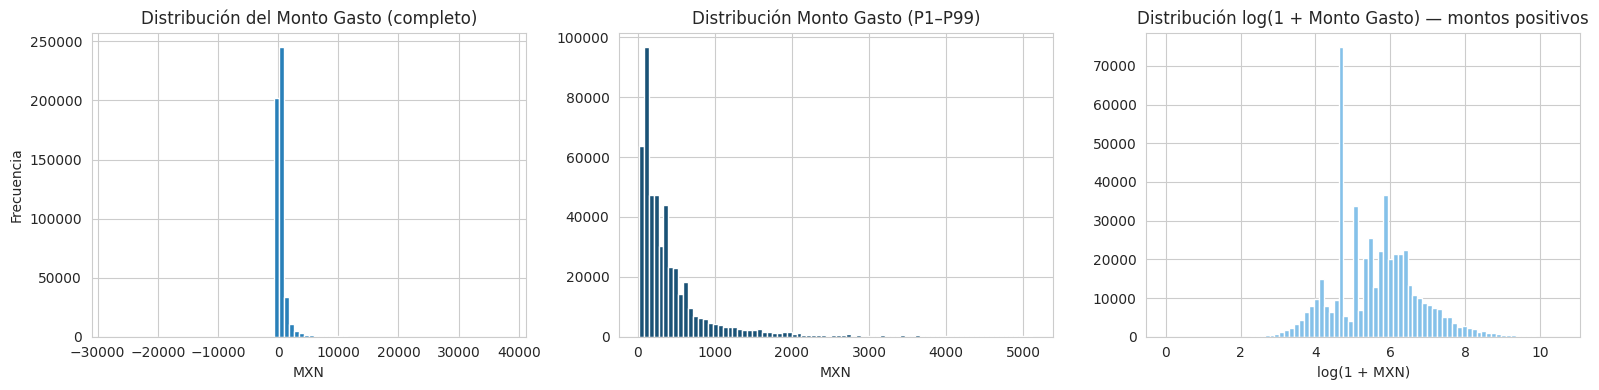

Asimetría (skew): 8.75
Curtosis          : 128.26

Escala log: asimetría = 0.34, curtosis = 0.21

HALLAZGO: La distribución es fuertemente asimétrica a la derecha (cola en montos altos).
La transformación log(1+x) la acerca considerablemente a la normal.
→ Se explorará log-transform como preprocesamiento para el modelo baseline (A3).
Los modelos de ensamble (XGBoost, RF) son robustos al sesgo, pero el baseline lineal lo requerirá.



In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma con todos los datos
axes[0].hist(df['Monto Gasto'], bins=80, color='#2980b9', edgecolor='white')
axes[0].set_title('Distribución del Monto Gasto (completo)')
axes[0].set_xlabel('MXN')
axes[0].set_ylabel('Frecuencia')

# Histograma sin extremos (P1–P99)
p1, p99 = df['Monto Gasto'].quantile([0.01, 0.99])
df_trim = df[(df['Monto Gasto'] >= p1) & (df['Monto Gasto'] <= p99)]
axes[1].hist(df_trim['Monto Gasto'], bins=80, color='#1a5276', edgecolor='white')
axes[1].set_title('Distribución Monto Gasto (P1–P99)')
axes[1].set_xlabel('MXN')

# Log-scale
pos_montos = df[df['Monto Gasto'] > 0]['Monto Gasto']
axes[2].hist(np.log1p(pos_montos), bins=80, color='#85c1e9', edgecolor='white')
axes[2].set_title('Distribución log(1 + Monto Gasto) — montos positivos')
axes[2].set_xlabel('log(1 + MXN)')

plt.tight_layout()
plt.show()

# Asimetría y curtosis
print(f'Asimetría (skew): {df["Monto Gasto"].skew():.2f}')
print(f'Curtosis          : {df["Monto Gasto"].kurt():.2f}')
print(f'\nEscala log: asimetría = {np.log1p(pos_montos).skew():.2f}, curtosis = {np.log1p(pos_montos).kurt():.2f}')
print("""
HALLAZGO: La distribución es fuertemente asimétrica a la derecha (cola en montos altos).
La transformación log(1+x) la acerca considerablemente a la normal.
→ Se explorará log-transform como preprocesamiento para el modelo baseline (A3).
Los modelos de ensamble (XGBoost, RF) son robustos al sesgo, pero el baseline lineal lo requerirá.
""")

### 4.2 Variables categóricas – cardinalidad y frecuencias

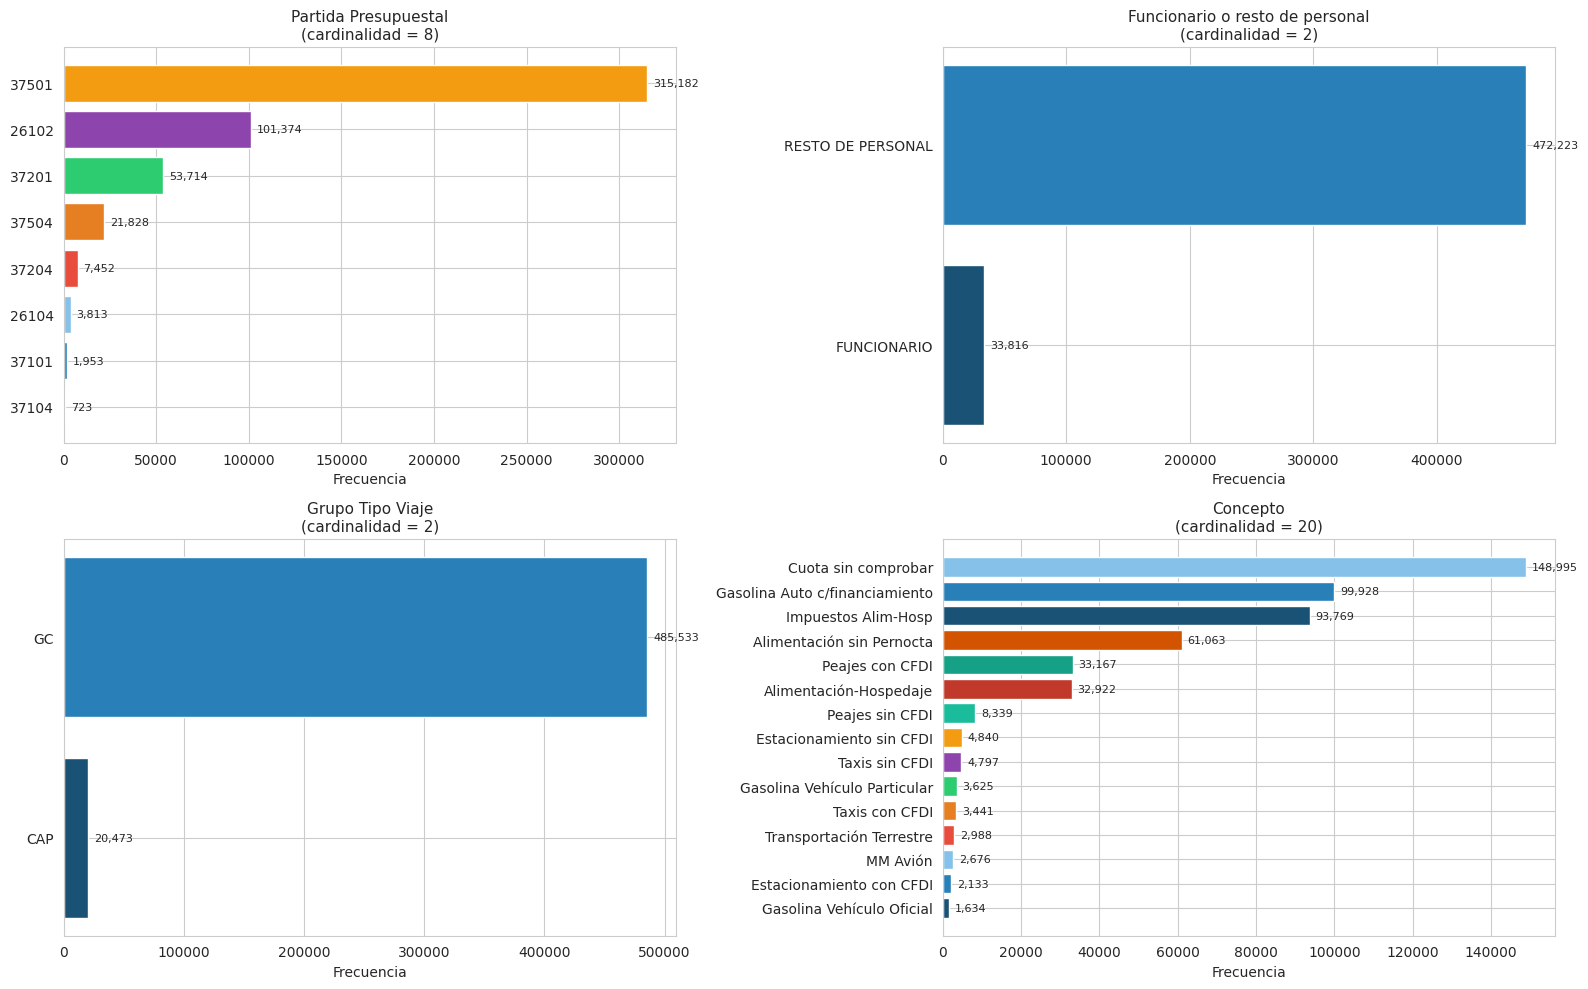


Cardinalidades:
  Partida Presupuestal: 8 valores únicos
  Funcionario o resto de personal: 2 valores únicos
  Grupo Tipo Viaje: 2 valores únicos
  Concepto: 20 valores únicos
  Clave Empleado: 1567 valores únicos
  Viaje: 22438 valores únicos
  Clave Centro Costo: 238 valores únicos


In [13]:
cat_cols = ['Partida Presupuestal', 'Funcionario o resto de personal',
            'Grupo Tipo Viaje', 'Concepto']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    top = vc.head(15)
    axes[i].barh(top.index.astype(str)[::-1], top.values[::-1],
                 color=PALETTE[:len(top)])
    axes[i].set_title(f'{col}\n(cardinalidad = {df[col].nunique()})', fontsize=11)
    axes[i].set_xlabel('Frecuencia')
    for j, v in enumerate(top.values[::-1]):
        axes[i].text(v + max(top.values)*0.01, j, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Tabla de cardinalidades
print('\nCardinalidades:')
for col in cat_cols + ['Clave Empleado', 'Viaje', 'Clave Centro Costo']:
    print(f'  {col}: {df[col].nunique()} valores únicos')

In [14]:
print("""
HALLAZGO – Variables categóricas:

Partida Presupuestal (8 valores):
  - Las partidas de viáticos resto de personal (37501) y cuota sin comprobar dominan en volumen.
  - Las de funcionario (<10% de empleados) representan ~6% de registros.
  - Cardinalidad baja → encoding directo (one-hot o ordinal) sin problema.

Tipo de Viaje (2 valores: GC / CAP):
  - GC (Gasto Corriente) = 96% de registros; CAP (Capacitación) = 4%.
  - Desequilibrio importante a considerar en el análisis bivariado por picos de gasto.

Concepto (alta cardinalidad ~25 conceptos):
  - Los 5 conceptos principales concentran >85% de registros.
  - 'Cuota sin comprobar' es el más frecuente (viáticos diarios sin comprobación).
  - 'Gasolina Auto c/financiamiento' domina las partidas 261xx.
  - En A2 se agruparán conceptos por familia (viáticos / transporte / gasolina / avión).

Clave Centro Costo (238 centros):
  - Alta cardinalidad; se agrupará a 13 unidades de primer nivel en A2 mediante
    la tabla de mapeo SAP → Centro Gestor → Unidad de primer nivel.
""")


HALLAZGO – Variables categóricas:

Partida Presupuestal (8 valores):
  - Las partidas de viáticos resto de personal (37501) y cuota sin comprobar dominan en volumen.
  - Las de funcionario (<10% de empleados) representan ~6% de registros.
  - Cardinalidad baja → encoding directo (one-hot o ordinal) sin problema.

Tipo de Viaje (2 valores: GC / CAP):
  - GC (Gasto Corriente) = 96% de registros; CAP (Capacitación) = 4%.
  - Desequilibrio importante a considerar en el análisis bivariado por picos de gasto.

Concepto (alta cardinalidad ~25 conceptos):
  - Los 5 conceptos principales concentran >85% de registros.
  - 'Cuota sin comprobar' es el más frecuente (viáticos diarios sin comprobación).
  - 'Gasolina Auto c/financiamiento' domina las partidas 261xx.
  - En A2 se agruparán conceptos por familia (viáticos / transporte / gasolina / avión).

Clave Centro Costo (238 centros):
  - Alta cardinalidad; se agrupará a 13 unidades de primer nivel en A2 mediante
    la tabla de mapeo SAP → Cent

### 4.3 Cobertura temporal

Registros por año (Fecha Contable):
      n_registros
anio             
2018       107781
2019       105208
2020        27788
2021        32424
2022        33732
2023        56795
2024        58952
2025        61012
2026        22347


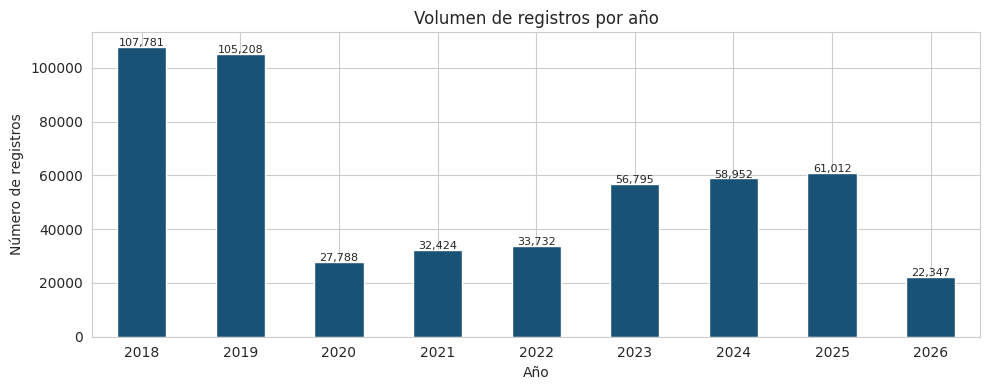


HALLAZGO – Cobertura temporal:
2018–2019: volumen normal (~100K registros/año).
2020–2022: caída marcada por COVID-19 (viajes reducidos, especialmente 2020).
2023–2025: recuperación progresiva y retorno a niveles pre-pandemia.
2026: solo ene–may (año en curso, incompleto).

→ El modelo de predicción debe considerar 2020–2022 como periodo atípico.
  Se evaluará si estos años se incluyen, excluyen o se ponderan menos en el entrenamiento.



In [15]:
df['anio'] = df['Fecha Contable'].dt.year
df['mes']  = df['Fecha Contable'].dt.month
df['anio_mes'] = df['Fecha Contable'].dt.to_period('M')

registros_anio = df.groupby('anio').size()
print('Registros por año (Fecha Contable):')
print(registros_anio.to_frame('n_registros'))

fig, ax = plt.subplots(figsize=(10, 4))
registros_anio.plot(kind='bar', ax=ax, color='#1a5276', edgecolor='white')
ax.set_title('Volumen de registros por año')
ax.set_xlabel('Año')
ax.set_ylabel('Número de registros')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 200,
            f'{int(p.get_height()):,}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print("""
HALLAZGO – Cobertura temporal:
2018–2019: volumen normal (~100K registros/año).
2020–2022: caída marcada por COVID-19 (viajes reducidos, especialmente 2020).
2023–2025: recuperación progresiva y retorno a niveles pre-pandemia.
2026: solo ene–may (año en curso, incompleto).

→ El modelo de predicción debe considerar 2020–2022 como periodo atípico.
  Se evaluará si estos años se incluyen, excluyen o se ponderan menos en el entrenamiento.
""")

---
## 5. Análisis Bivariado
### 5.1 Gasto mensual total – serie de tiempo

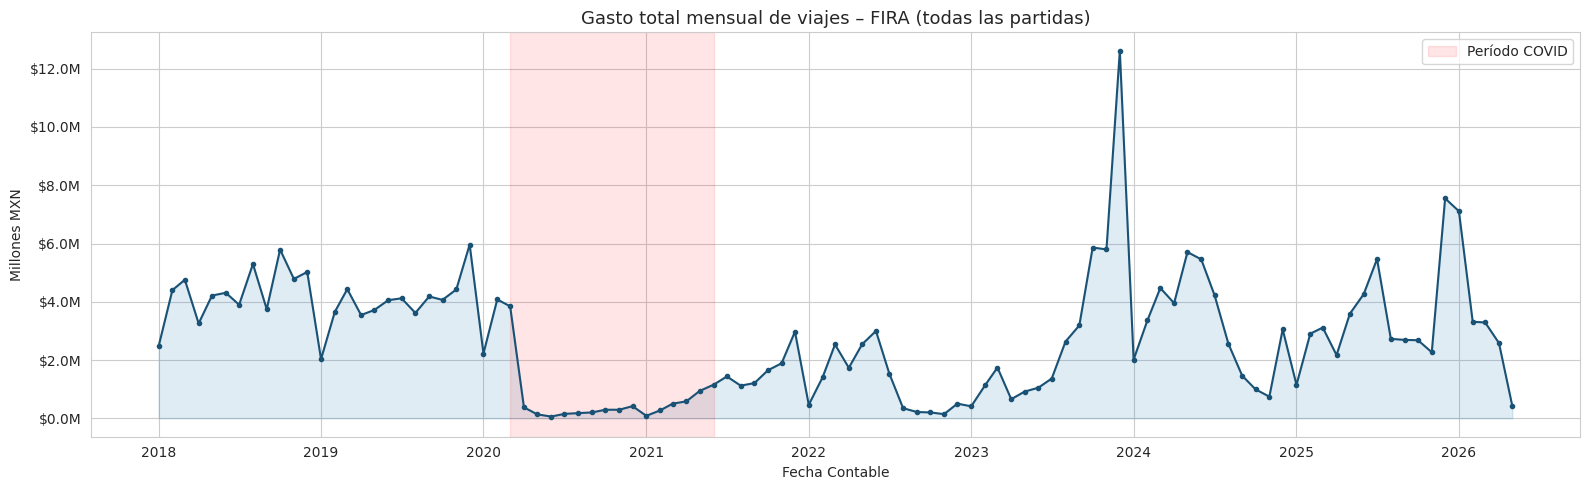

In [16]:
gasto_mensual = df.groupby('anio_mes')['Monto Gasto'].sum().reset_index()
gasto_mensual['anio_mes_dt'] = gasto_mensual['anio_mes'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(gasto_mensual['anio_mes_dt'], gasto_mensual['Monto Gasto']/1e6,
        color='#1a5276', linewidth=1.5, marker='o', markersize=3)
ax.fill_between(gasto_mensual['anio_mes_dt'], gasto_mensual['Monto Gasto']/1e6,
                alpha=0.15, color='#2980b9')
ax.set_title('Gasto total mensual de viajes – FIRA (todas las partidas)', fontsize=13)
ax.set_xlabel('Fecha Contable')
ax.set_ylabel('Millones MXN')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))

# Marcar COVID
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.1, color='red', label='Período COVID')
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Gasto mensual por partida presupuestal

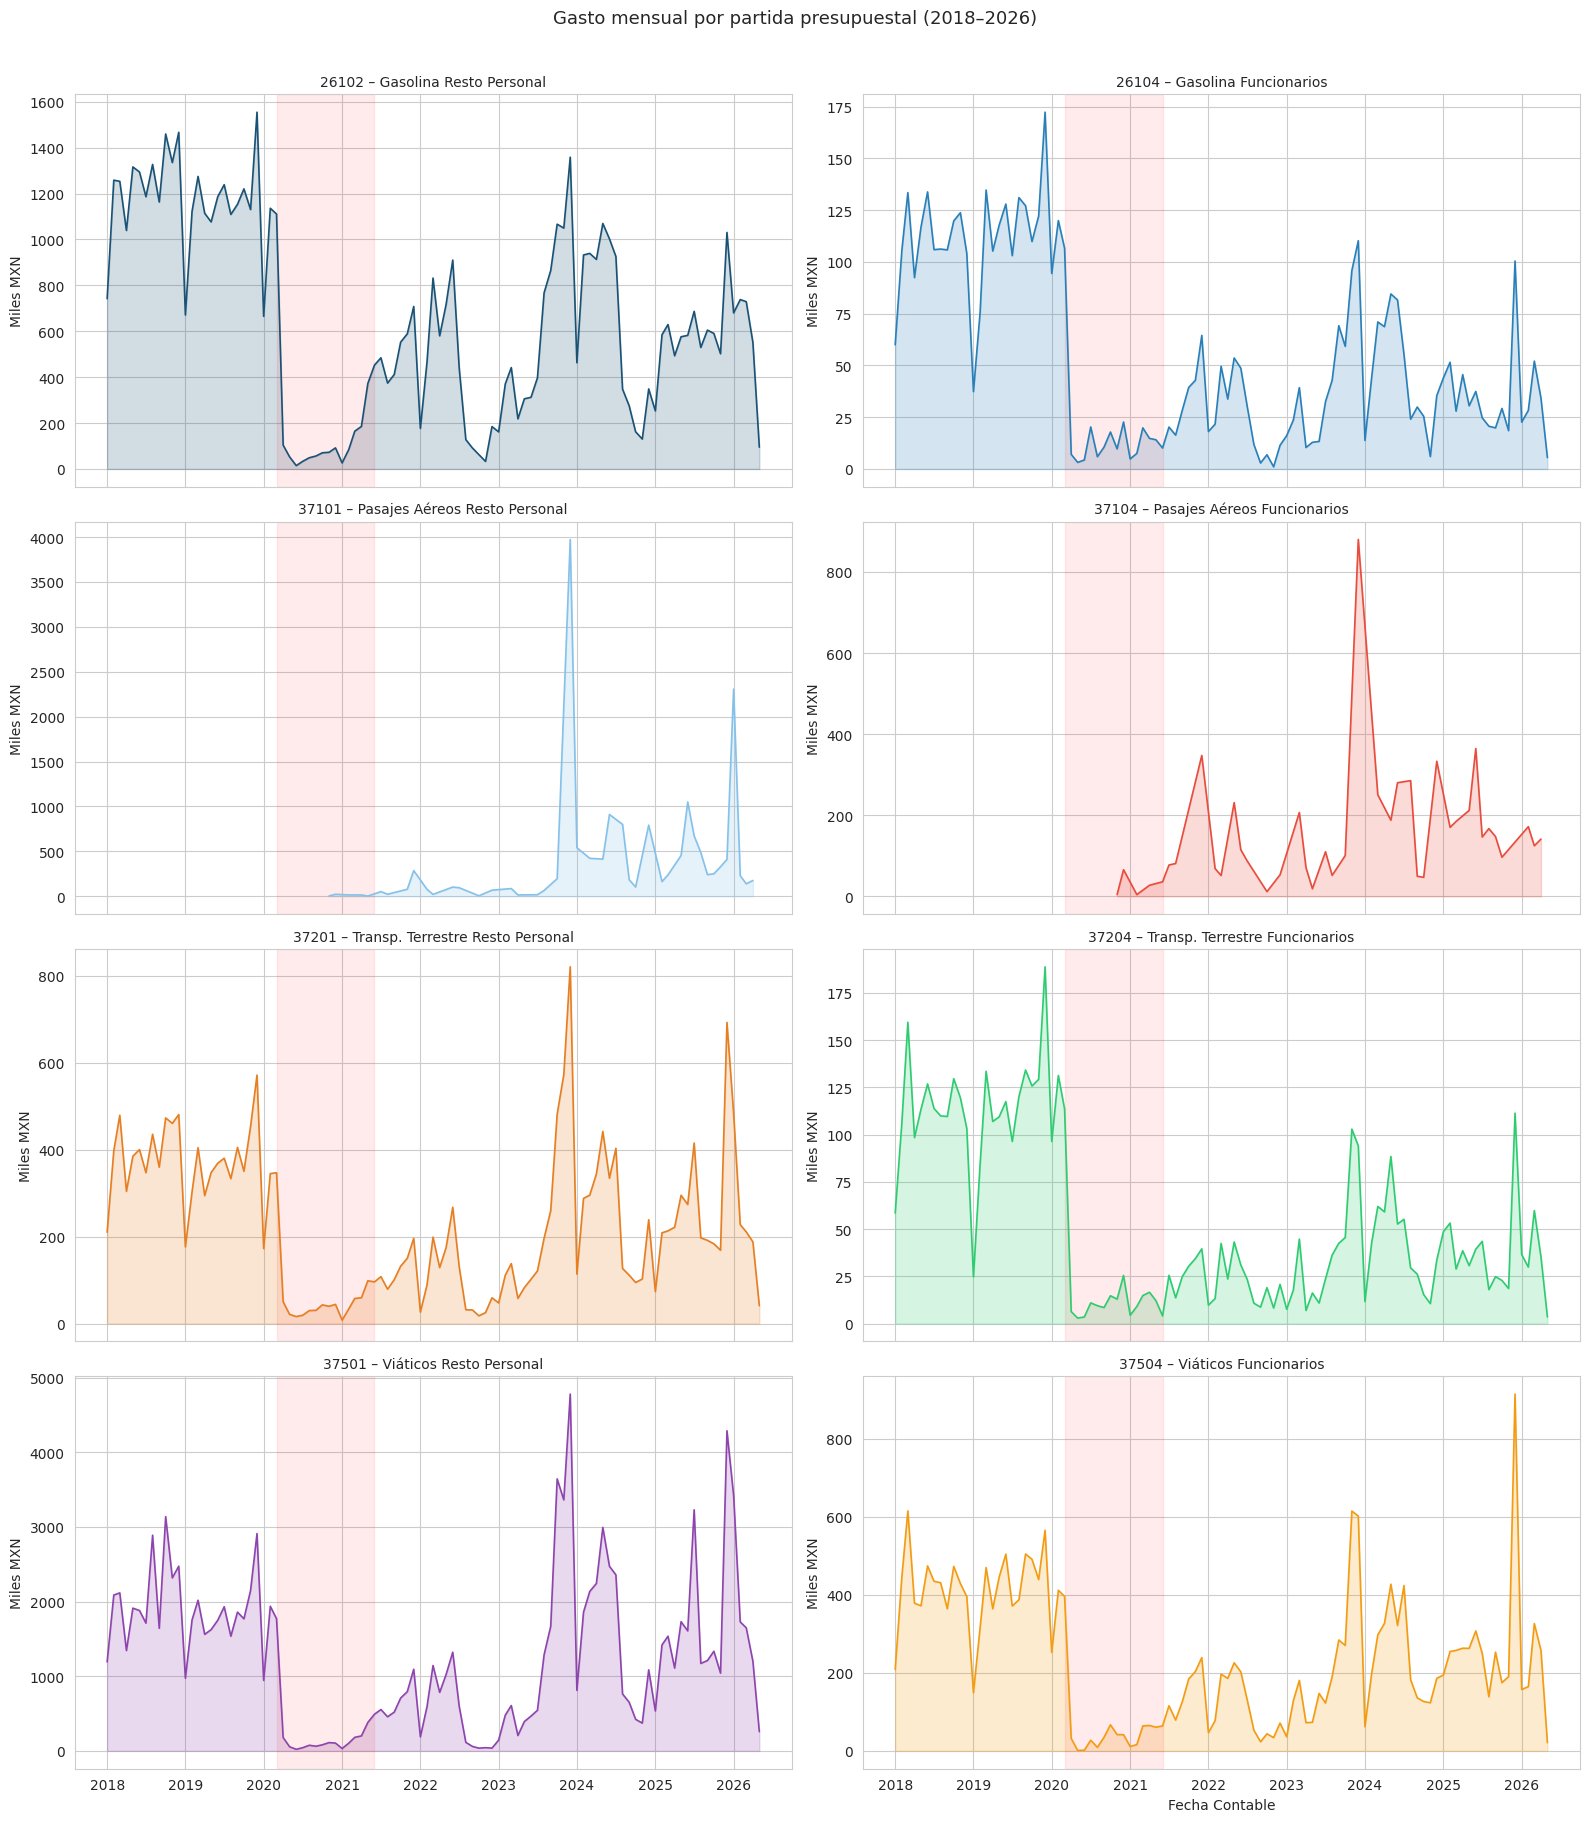

In [17]:
gasto_partida_mes = (df.groupby(['anio_mes', 'Partida Presupuestal'])['Monto Gasto']
                       .sum().reset_index())
gasto_partida_mes['fecha'] = gasto_partida_mes['anio_mes'].dt.to_timestamp()

fig, axes = plt.subplots(4, 2, figsize=(16, 18), sharex=True)
axes = axes.flatten()

partidas_labels = {
    26102: '26102 – Gasolina Resto Personal',
    26104: '26104 – Gasolina Funcionarios',
    37101: '37101 – Pasajes Aéreos Resto Personal',
    37104: '37104 – Pasajes Aéreos Funcionarios',
    37201: '37201 – Transp. Terrestre Resto Personal',
    37204: '37204 – Transp. Terrestre Funcionarios',
    37501: '37501 – Viáticos Resto Personal',
    37504: '37504 – Viáticos Funcionarios',
}

for i, partida in enumerate(PARTIDAS_MODELO):
    data = gasto_partida_mes[gasto_partida_mes['Partida Presupuestal'] == partida]
    axes[i].plot(data['fecha'], data['Monto Gasto']/1e3, color=PALETTE[i], linewidth=1.2)
    axes[i].fill_between(data['fecha'], data['Monto Gasto']/1e3, alpha=0.2, color=PALETTE[i])
    axes[i].set_title(partidas_labels[partida], fontsize=10)
    axes[i].set_ylabel('Miles MXN')
    axes[i].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
                    alpha=0.08, color='red')

axes[-1].set_xlabel('Fecha Contable')
plt.suptitle('Gasto mensual por partida presupuestal (2018–2026)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Estacionalidad mensual

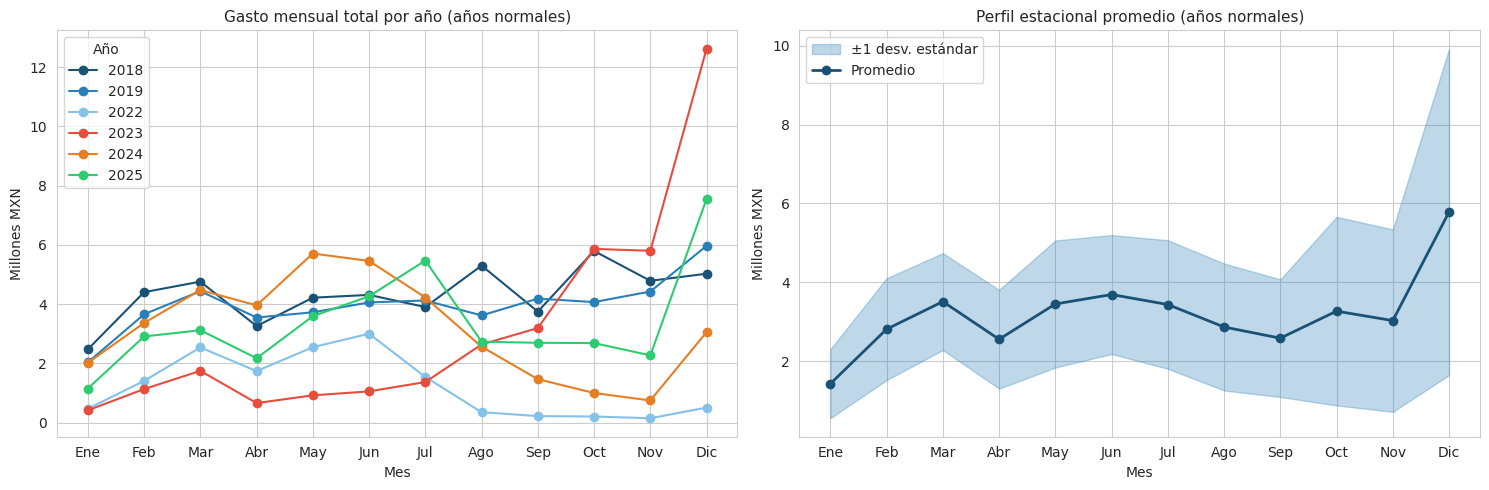


HALLAZGO – Estacionalidad:
Se observa un patrón recurrente:
  - Enero-Febrero: gasto moderado (inicio de ejercicio, procesos de autorización).
  - Marzo-Junio: escalada progresiva hacia el máximo de medio año.
  - Julio-Agosto: posible valle (vacaciones, menor actividad operativa).
  - Septiembre-Noviembre: repunte hacia el cierre del ejercicio.
  - Diciembre: caída por cierre presupuestal y fechas festivas.

Este patrón es consistente entre años, lo que valida la inclusión del mes como
feature en el modelo predictivo.



In [18]:
# Solo años 'normales' para estacionalidad (excluimos 2020-2021 COVID y 2026 incompleto)
df_norm = df[df['anio'].isin([2018, 2019, 2022, 2023, 2024, 2025])]

estac = df_norm.groupby(['anio', 'mes'])['Monto Gasto'].sum().reset_index()
estac_pivot = estac.pivot(index='mes', columns='anio', values='Monto Gasto')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Líneas por año
for anio in estac_pivot.columns:
    axes[0].plot(estac_pivot.index, estac_pivot[anio]/1e6, marker='o', label=str(anio), linewidth=1.5)
axes[0].set_title('Gasto mensual total por año (años normales)', fontsize=11)
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Millones MXN')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
axes[0].legend(title='Año', loc='upper left')

# Promedio y banda
media_mes = estac_pivot.mean(axis=1)
std_mes   = estac_pivot.std(axis=1)
axes[1].fill_between(estac_pivot.index, (media_mes - std_mes)/1e6, (media_mes + std_mes)/1e6,
                     alpha=0.3, color='#2980b9', label='±1 desv. estándar')
axes[1].plot(estac_pivot.index, media_mes/1e6, color='#1a5276', marker='o', linewidth=2, label='Promedio')
axes[1].set_title('Perfil estacional promedio (años normales)', fontsize=11)
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Millones MXN')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
axes[1].legend()

plt.tight_layout()
plt.show()

print("""
HALLAZGO – Estacionalidad:
Se observa un patrón recurrente:
  - Enero-Febrero: gasto moderado (inicio de ejercicio, procesos de autorización).
  - Marzo-Junio: escalada progresiva hacia el máximo de medio año.
  - Julio-Agosto: posible valle (vacaciones, menor actividad operativa).
  - Septiembre-Noviembre: repunte hacia el cierre del ejercicio.
  - Diciembre: caída por cierre presupuestal y fechas festivas.

Este patrón es consistente entre años, lo que valida la inclusión del mes como
feature en el modelo predictivo.
""")

### 5.4 Gasto Corriente vs. Capacitación

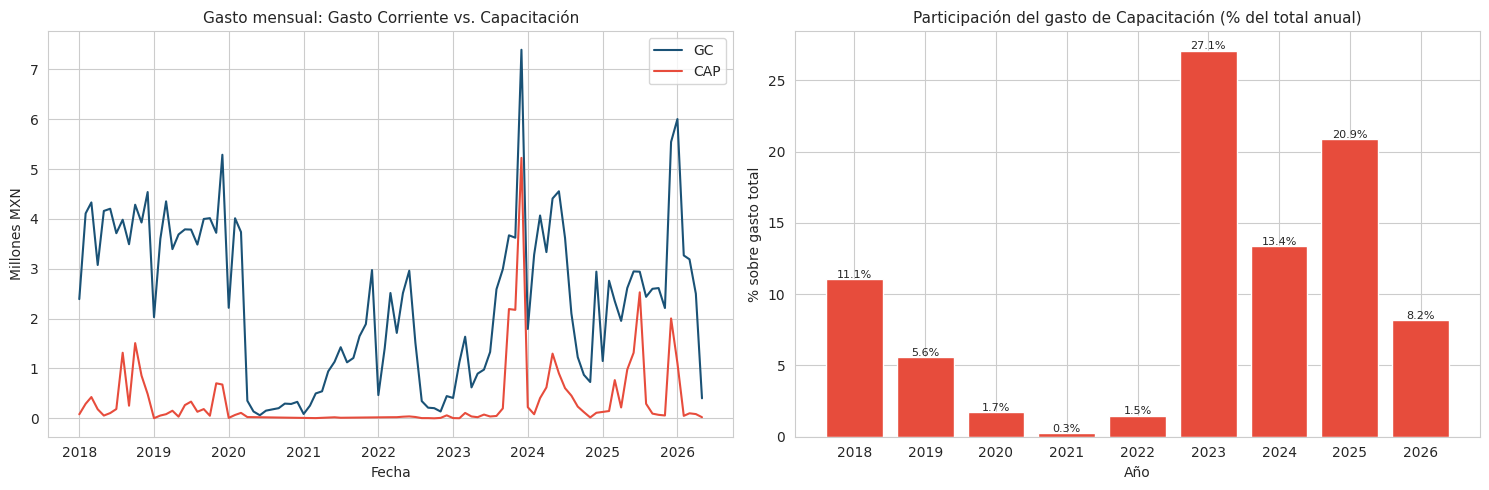


HALLAZGO – GC vs. CAP:
Los viajes de Capacitación (CAP) representan ~4–8% del gasto total pero generan
picos abruptos en periodos específicos (cursos masivos). Su comportamiento es
más difícil de predecir con tendencias históricas; depende del calendario de
eventos de FIRA.

→ Se considerará modelar GC y CAP por separado o incluir 'Grupo Tipo Viaje'
  como feature categórico con interacción con el mes y la unidad.



In [19]:
gasto_tipo = df.groupby(['anio_mes', 'Grupo Tipo Viaje'])['Monto Gasto'].sum().reset_index()
gasto_tipo['fecha'] = gasto_tipo['anio_mes'].dt.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for tipo, color in [('GC', '#1a5276'), ('CAP', '#e74c3c')]:
    data = gasto_tipo[gasto_tipo['Grupo Tipo Viaje'] == tipo]
    axes[0].plot(data['fecha'], data['Monto Gasto']/1e6, label=tipo, color=color, linewidth=1.5)

axes[0].set_title('Gasto mensual: Gasto Corriente vs. Capacitación', fontsize=11)
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Millones MXN')
axes[0].legend()

# Participación porcentual de CAP por año
part_anio = df.groupby(['anio','Grupo Tipo Viaje'])['Monto Gasto'].sum().unstack(fill_value=0)
part_anio['%_CAP'] = part_anio.get('CAP', 0) / (part_anio.get('CAP', 0) + part_anio.get('GC', 0)) * 100
axes[1].bar(part_anio.index.astype(str), part_anio['%_CAP'], color='#e74c3c', edgecolor='white')
axes[1].set_title('Participación del gasto de Capacitación (% del total anual)', fontsize=11)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('% sobre gasto total')
for p in axes[1].patches:
    axes[1].text(p.get_x() + p.get_width()/2, p.get_height() + 0.1,
                 f'{p.get_height():.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("""
HALLAZGO – GC vs. CAP:
Los viajes de Capacitación (CAP) representan ~4–8% del gasto total pero generan
picos abruptos en periodos específicos (cursos masivos). Su comportamiento es
más difícil de predecir con tendencias históricas; depende del calendario de
eventos de FIRA.

→ Se considerará modelar GC y CAP por separado o incluir 'Grupo Tipo Viaje'
  como feature categórico con interacción con el mes y la unidad.
""")

### 5.5 Gasto por partida: distribución con boxplots

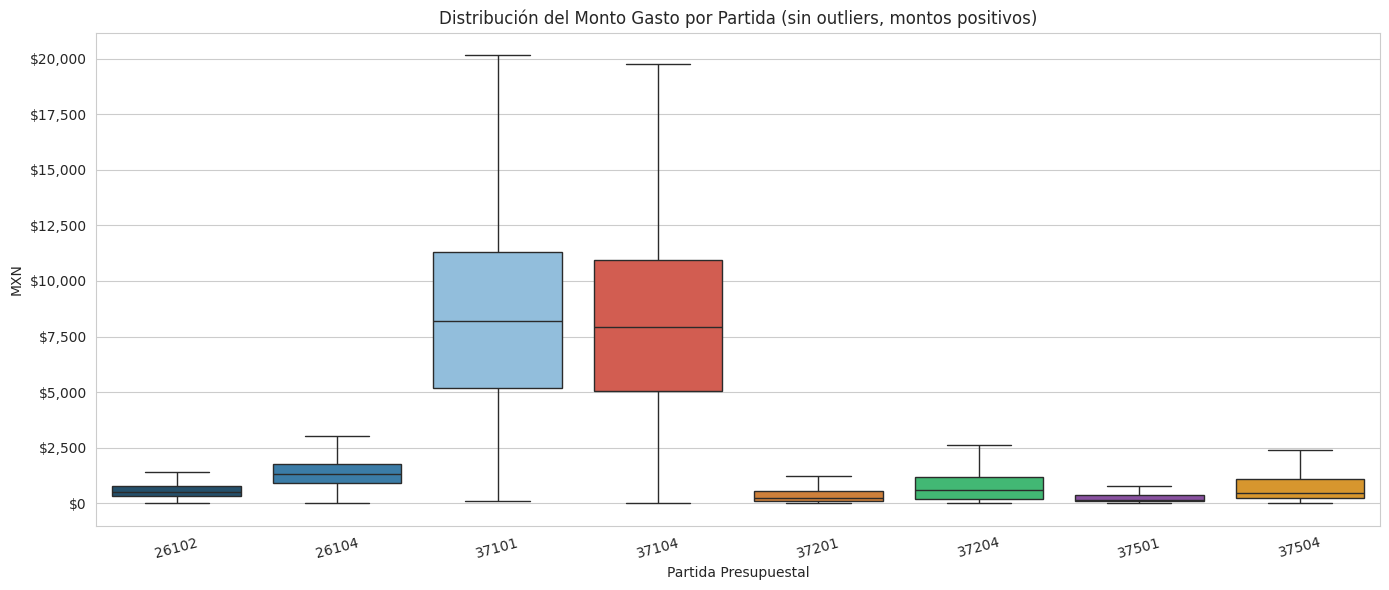

                           n    media  mediana      std       P95
Partida Presupuestal                                             
26102                 101370   649.63   500.00   500.98  1,600.11
26104                   3812 1,397.30 1,311.71   697.17  2,568.80
37101                   1953 8,509.32 8,215.47 4,340.66 16,225.80
37104                    723 8,373.31 7,923.00 4,518.19 15,483.00
37201                  53202   427.91   250.00   491.63  1,396.00
37204                   7295   715.24   600.00   557.87  1,614.99
37501                 312644   408.33   170.00   965.45  1,591.71
37504                  21550 1,104.14   460.27 1,635.53  4,755.03


In [20]:
fig, ax = plt.subplots(figsize=(14, 6))
df_pos = df[df['Monto Gasto'] > 0].copy()
df_pos['Partida'] = df_pos['Partida Presupuestal'].astype(str)

sns.boxplot(data=df_pos, x='Partida', y='Monto Gasto',
            order=[str(p) for p in PARTIDAS_MODELO],
            palette=PALETTE, showfliers=False, ax=ax)
ax.set_title('Distribución del Monto Gasto por Partida (sin outliers, montos positivos)', fontsize=12)
ax.set_xlabel('Partida Presupuestal')
ax.set_ylabel('MXN')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Estadísticas por partida
stats_partida = df_pos.groupby('Partida Presupuestal')['Monto Gasto'].agg(
    ['count','mean','median','std', lambda x: x.quantile(0.95)]
).round(2)
stats_partida.columns = ['n','media','mediana','std','P95']
print(stats_partida)

### 5.6 Gasto mensual agregado por partida (unidad de observación del modelo)

In [21]:
# Agregar al nivel: año-mes × partida (sin desagregación por centro costo aún, pendiente mapeo)
target_df = (df.groupby(['anio_mes', 'Partida Presupuestal'])['Monto Gasto']
               .sum().reset_index())
target_df['fecha'] = target_df['anio_mes'].dt.to_timestamp()

print('Estadísticas del gasto mensual por partida (variable objetivo agregada):')
stats_target = target_df.groupby('Partida Presupuestal')['Monto Gasto'].agg(
    ['count','mean','median','std','min','max']
).round(0)
stats_target.columns = ['n_meses','media_mens','mediana_mens','std_mens','min_mens','max_mens']
print(stats_target)

print("""
HALLAZGO – Variable objetivo (gasto mensual por partida):
La dispersión (std) respecto a la media es alta en todas las partidas, especialmente
en viáticos (375xx) que son las de mayor volumen. Esto confirma que el modelo
deberá capturar estacionalidad y eventos excepcionales para obtener predicciones útiles.
""")

Estadísticas del gasto mensual por partida (variable objetivo agregada):
                      n_meses   media_mens  mediana_mens     std_mens  \
Partida Presupuestal                                                    
26102                     101   651,986.00    588,620.00   435,179.00   
26104                     101    52,724.00     37,381.00    43,091.00   
37101                      45   369,304.00    163,372.00   682,665.00   
37104                      40   151,348.00    112,211.00   153,079.00   
37201                     101   225,315.00    196,048.00   169,423.00   
37204                     101    51,657.00     34,376.00    44,879.00   
37501                     101 1,263,040.00  1,143,091.00 1,035,419.00   
37504                     101   235,535.00    196,817.00   177,045.00   

                      min_mens     max_mens  
Partida Presupuestal                         
26102                14,599.00 1,554,447.00  
26104                 1,030.00   172,335.00  
37101       

### 5.7 Análisis de outliers

In [22]:
# Outliers por IQR en Monto Gasto
Q1 = df['Monto Gasto'].quantile(0.25)
Q3 = df['Monto Gasto'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Monto Gasto'] < lower) | (df['Monto Gasto'] > upper)]
print(f'Outliers por IQR: {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)')
print(f'Límite inferior: ${lower:,.2f}')
print(f'Límite superior: ${upper:,.2f}')

print('\nOutliers por partida:')
print(outliers.groupby('Partida Presupuestal').agg(
    n=('Monto Gasto','count'),
    monto_max=('Monto Gasto','max'),
    monto_min=('Monto Gasto','min')
))

# Top 10 montos más altos
print('\nTop 10 montos más altos:')
print(df.nlargest(10, 'Monto Gasto')[['Concepto','Partida Presupuestal',
                                       'Fecha Contable','Monto Gasto',
                                       'Funcionario o resto de personal']])

print("""
HALLAZGO – Outliers:
Los valores extremos en montos altos son plausibles dados los topes de viáticos:
un funcionario con varios días de hospedaje + alimentación puede llegar a
$2,704/día × varios días + avión. No deben eliminarse automáticamente.

Estrategia (A2):
  - Verificar contra tarifas máximas vigentes (¿supera el tope? → posible error SAP).
  - Los que superen el tope tarifario se etiquetan como candidatos a revisión.
  - A nivel de agregado mensual por unidad×partida, los outliers se suavizan.
""")

Outliers por IQR: 49,428 (9.8%)
Límite inferior: $-522.12
Límite superior: $1,152.88

Outliers por partida:
                          n  monto_max  monto_min
Partida Presupuestal                             
26102                 11070  12,991.78  -1,169.97
26104                  2261   6,491.76  -1,367.40
37101                  1928  27,729.00   1,169.95
37104                   712  37,849.80   1,211.64
37201                  5088  23,200.00  -1,313.00
37204                  1956   5,875.00   1,153.00
37501                 21221  35,464.32 -27,667.93
37504                  5192  30,258.80  -2,782.37

Top 10 montos más altos:
                      Concepto  Partida Presupuestal Fecha Contable  \
64676                 MM Avión                 37104     2022-06-15   
248896  Alimentación-Hospedaje                 37501     2024-06-05   
65267                 MM Avión                 37104     2026-02-24   
502238  Alimentación-Hospedaje                 37501     2025-07-07   
502416  Ali

---
## 6. Normalización de montos por cambio de tarifas

### 6.1 Marco conceptual del problema

El dataset cubre 2018–2026, período en que las tarifas máximas de viáticos (partidas 375xx) cambiaron dos veces:
- **Zona A / Zona B** (hasta julio 2023 para algunas tablas, hasta junio 2025 para otras)
- **Tarifa única** vigente desde el 30 de junio de 2025

Comparar montos de viáticos de 2019 con los de 2025 sin ajuste produce sesgo en el modelo.
A continuación se propone y calcula el índice de normalización.

In [23]:
# =============================================================================
# TABLAS DE TARIFAS HISTÓRICAS (viáticos nacionales, monto base sin impuestos)
# Fuente: Normatividad FIRA / Avance 0
# =============================================================================

# Cada registro: (fecha_inicio_vigencia, fecha_fin_vigencia,
#                 hosp_alim_func, hosp_alim_resto,
#                 alim_sinpernocta_func, alim_sinpernocta_resto,
#                 cuota_func, cuota_resto)
#
# NOTA: Los valores de Zona A se usan como representativos del período
# hasta que se obtengan las tablas exactas del sponsor.
# Se deberá actualizar con los valores reales de cada vigencia.

TARIFAS_HISTORICAS = [
    {
        'vigencia_inicio': '2018-01-01',
        'vigencia_fin'   : '2021-12-31',
        'descripcion'    : 'Zona A/B hasta 2021 (estimado – confirmar con sponsor)',
        # Funcionario
        'hosp_alim_func'          : 2218.0,  # hospedaje + alimentación
        'alim_sinpernocta_func'   :  522.0,
        'cuota_func'              :  200.0,
        # Resto de personal
        'hosp_alim_resto'         : 1347.0,
        'alim_sinpernocta_resto'  :  507.0,
        'cuota_resto'             :  191.0,
    },
    {
        'vigencia_inicio': '2022-01-01',
        'vigencia_fin'   : '2025-06-29',
        'descripcion'    : 'Zona A/B 2022–jun 2025 (estimado – confirmar con sponsor)',
        'hosp_alim_func'          : 2500.0,
        'alim_sinpernocta_func'   :  600.0,
        'cuota_func'              :  230.0,
        'hosp_alim_resto'         : 1510.0,
        'alim_sinpernocta_resto'  :  570.0,
        'cuota_resto'             :  210.0,
    },
    {
        'vigencia_inicio': '2025-06-30',
        'vigencia_fin'   : '2099-12-31',
        'descripcion'    : 'Tarifa única desde 30-jun-2025 (A0)',
        'hosp_alim_func'          : 2704.0,
        'alim_sinpernocta_func'   :  647.0,
        'cuota_func'              :  260.0,
        'hosp_alim_resto'         : 1635.0,
        'alim_sinpernocta_resto'  :  620.0,
        'cuota_resto'             :  230.0,
    },
]

tarifas_df = pd.DataFrame(TARIFAS_HISTORICAS)
tarifas_df['vigencia_inicio'] = pd.to_datetime(tarifas_df['vigencia_inicio'])
tarifas_df['vigencia_fin']    = pd.to_datetime(tarifas_df['vigencia_fin'])
print('Tabla de tarifas históricas cargada:')
tarifas_df[['vigencia_inicio','vigencia_fin','descripcion',
             'hosp_alim_func','hosp_alim_resto','cuota_func','cuota_resto']]

Tabla de tarifas históricas cargada:


,vigencia_inicio,vigencia_fin,descripcion,hosp_alim_func,hosp_alim_resto,cuota_func,cuota_resto
0,2018-01-01,2021-12-31,Zona A/B hasta 2021 (estimado – confirmar con ...,"2,218.00","1,347.00",200.00,191.00
1,2022-01-01,2025-06-29,Zona A/B 2022–jun 2025 (estimado – confirmar c...,"2,500.00","1,510.00",230.00,210.00
2,2025-06-30,2099-12-31,Tarifa única desde 30-jun-2025 (A0),"2,704.00","1,635.00",260.00,230.00


In [24]:
# =============================================================================
# ESTRATEGIA DE NORMALIZACIÓN PROPUESTA
#
# Objetivo: expresar todos los montos históricos en unidades de la tarifa
# vigente actual ("tarifa única 2025"), para que el modelo vea magnitudes
# comparables a lo largo del tiempo.
#
# Método: "Fracción de tarifa ejercida"
#   fraccion = monto_base_concepto / tarifa_maxima_vigente_en_fecha_inicio_viaje
#
# Interpretación: qué proporción del tope disponible se utilizó.
#   fraccion = 1.0 → el empleado usó exactamente el tope.
#   fraccion = 0.8 → usó 80% del tope disponible.
#
# Para reconstruir un monto en pesos comparables al período actual:
#   monto_normalizado = fraccion × tarifa_maxima_actual
#
# CONCEPTOS QUE APLICA (partidas 375xx):
#   Alimentación-Hospedaje       → tarifa hosp_alim (funcionario o resto)
#   Alimentación sin Pernocta    → tarifa alim_sinpernocta
#   Cuota sin comprobar          → tarifa cuota
#   Impuestos Alim-Hosp          → NO aplica (son impuestos, no van contra tope)
#   Tintorería                   → NO aplica (concepto auxiliar)
#
# Las partidas 26xxx (gasolina) y 37201/37204 (transporte terrestre) NO tienen
# tope tarifario diario definido de la misma manera → se normalizan por inflación.
# Las partidas 371xx (aviones) tampoco tienen tope unitario → normalización por inflación.
#
# NORMALIZACIÓN POR INFLACIÓN (partidas no viáticos):
#   monto_real = monto_nominal / inpc_mes_registro × inpc_base (dic 2024)
#   (INPC se integrará como fuente externa en A2; aquí se documenta la metodología)
# =============================================================================

def get_tarifa(fecha, categoria, concepto):
    """
    Devuelve la tarifa máxima vigente para una fecha, categoría de empleado
    y concepto de viático.
    Retorna None si el concepto no tiene tope tarifario definido.
    """
    for _, row in tarifas_df.iterrows():
        if row['vigencia_inicio'] <= fecha <= row['vigencia_fin']:
            cat = 'func' if categoria == 'FUNCIONARIO' else 'resto'
            if 'Alimentación-Hospedaje' in concepto or 'Alim-Hosp' in concepto:
                # Solo el monto base (no impuestos)
                return row[f'hosp_alim_{cat}']
            elif 'Alimentación sin Pernocta' in concepto:
                return row[f'alim_sinpernocta_{cat}']
            elif 'Cuota sin comprobar' in concepto:
                return row[f'cuota_{cat}']
            else:
                return None  # Impuestos, tintorería, etc.
    return None


# Aplicar solo a partidas 375xx con Fecha inicio disponible
df_viaticos = df[(df['Partida Presupuestal'].isin([37501, 37504])) &
                  (df['Fecha inicio'].notna()) &
                  (df['Monto Gasto'] > 0)].copy()

print(f'Registros de viáticos con fecha inicio: {len(df_viaticos):,}')

# Calcular tarifa máxima aplicable por registro
df_viaticos['tarifa_maxima'] = df_viaticos.apply(
    lambda r: get_tarifa(
        r['Fecha inicio'],
        r['Funcionario o resto de personal'],
        r['Concepto']
    ), axis=1
)

# Fracción ejercida (solo para conceptos con tope definido)
mask_con_tarifa = df_viaticos['tarifa_maxima'].notna()
df_viaticos.loc[mask_con_tarifa, 'fraccion_tarifa'] = (
    df_viaticos.loc[mask_con_tarifa, 'Monto Gasto'] /
    df_viaticos.loc[mask_con_tarifa, 'tarifa_maxima']
)

print(f'\nRegistros con tarifa aplicable: {mask_con_tarifa.sum():,}')
print(f'Registros sin tarifa (impuestos/otros): {(~mask_con_tarifa).sum():,}')
print('\nEstadísticas de fracción de tarifa ejercida:')
print(df_viaticos.loc[mask_con_tarifa, 'fraccion_tarifa'].describe().to_frame().T.round(3))

Registros de viáticos con fecha inicio: 334,194



Registros con tarifa aplicable: 333,378
Registros sin tarifa (impuestos/otros): 816

Estadísticas de fracción de tarifa ejercida:
                     count  mean  std  min  25%  50%  75%   max
fraccion_tarifa 333,378.00  0.74 0.89 0.00 0.23 0.56 0.88 25.19


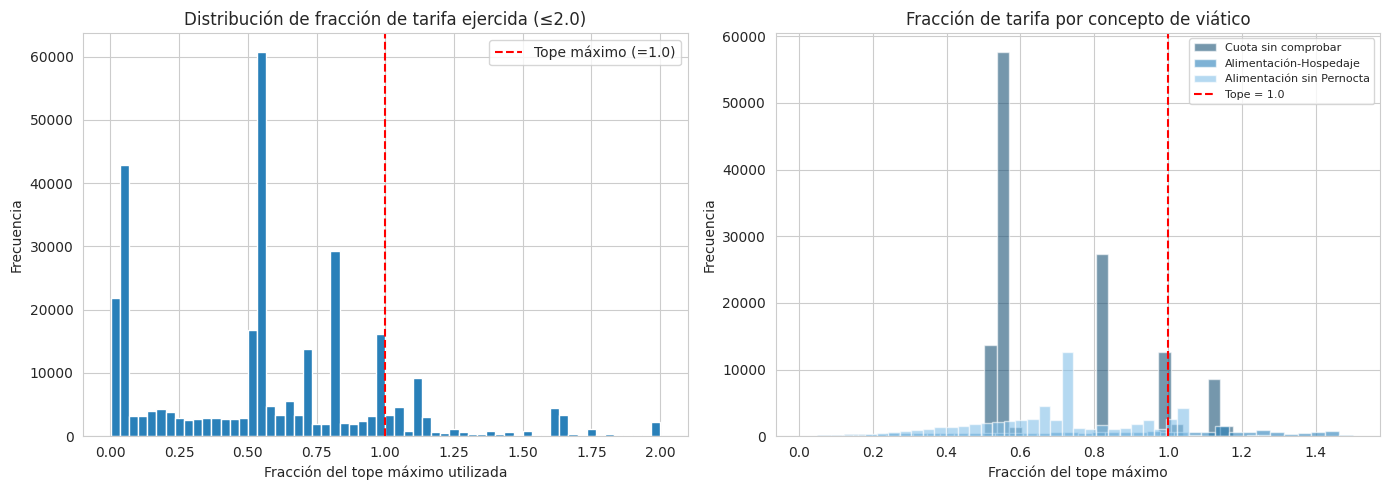


Registros que superan el tope en más de 5%: 55970
Porcentaje sobre registros con tarifa: 16.79%


In [25]:
# Visualizar la distribución de la fracción de tarifa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

frac_validas = df_viaticos.loc[
    mask_con_tarifa & (df_viaticos['fraccion_tarifa'] <= 2.0),
    'fraccion_tarifa'
]

axes[0].hist(frac_validas, bins=60, color='#2980b9', edgecolor='white')
axes[0].axvline(1.0, color='red', linestyle='--', label='Tope máximo (=1.0)')
axes[0].set_title('Distribución de fracción de tarifa ejercida (≤2.0)')
axes[0].set_xlabel('Fracción del tope máximo utilizada')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Por concepto
conceptos_viaticos = ['Cuota sin comprobar', 'Alimentación-Hospedaje', 'Alimentación sin Pernocta']
for concepto in conceptos_viaticos:
    data = df_viaticos.loc[
        mask_con_tarifa & (df_viaticos['Concepto'] == concepto) &
        (df_viaticos['fraccion_tarifa'] <= 1.5),
        'fraccion_tarifa'
    ]
    if len(data) > 0:
        axes[1].hist(data, bins=40, alpha=0.6, label=concepto)

axes[1].axvline(1.0, color='red', linestyle='--', label='Tope = 1.0')
axes[1].set_title('Fracción de tarifa por concepto de viático')
axes[1].set_xlabel('Fracción del tope máximo')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Cuántos superan el tope (posibles errores SAP)
sup_tope = (df_viaticos.loc[mask_con_tarifa, 'fraccion_tarifa'] > 1.05).sum()
print(f'\nRegistros que superan el tope en más de 5%: {sup_tope}')
print(f'Porcentaje sobre registros con tarifa: {sup_tope/mask_con_tarifa.sum()*100:.2f}%')

In [26]:
print("""
PROPUESTA DE NORMALIZACIÓN – Resumen ejecutivo
===============================================

PROBLEMA:
El dataset cubre 2018–2026, con al menos dos cambios de tarifas máximas de viáticos.
Los montos nominales de 2019 no son directamente comparables con los de 2025 porque
el tope disponible era distinto; dos empleados que usaron exactamente su tope completo
aparecen con montos diferentes en el historial.

SOLUCIÓN – Variable 'fraccion_tarifa' (partidas 375xx):
  fraccion = monto_base / tarifa_maxima_vigente_en_fecha_inicio_viaje

  Ventajas:
    ✓ Normaliza automáticamente ante cualquier cambio de tarifa.
    ✓ Interpretable: fraccion=1.0 significa que el empleado agotó su tope.
    ✓ Permite detectar anomalías (fraccion > 1.05 sugiere error en SAP o
      excepción autorizada explícitamente).
    ✓ La distribución resultante muestra claramente si los empleados usan
      sistemáticamente el tope completo o solo una fracción de él.

  Limitación: requiere conocer la tarifa exacta vigente en cada fecha
  (pendiente validación de los valores 2018–2021 con el sponsor).

SOLUCIÓN – Índice INPC (partidas 261xx, 372xx, 371xx):
  Las partidas de gasolina, transporte terrestre y aviones no tienen tope
  tarifario unitario → se deflactan con el INPC (base fija: dic-2024):
    monto_real = monto_nominal × (INPC_base / INPC_mes)

  El INPC mensual se integrará como fuente externa en A2. BanxICo publica
  la serie histórica en su portal de datos abiertos.

NOTA ESPECIAL – Partidas 371xx (aviones):
  Disponibles en el dataset solo a partir de septiembre 2020 (inicio del
  proceso con agencia externa). Los años anteriores no tienen esta partida
  disponible. El modelo predictivo para 371xx utilizará únicamente el
  histórico sep-2020 a la fecha.
""")


PROPUESTA DE NORMALIZACIÓN – Resumen ejecutivo

PROBLEMA:
El dataset cubre 2018–2026, con al menos dos cambios de tarifas máximas de viáticos.
Los montos nominales de 2019 no son directamente comparables con los de 2025 porque
el tope disponible era distinto; dos empleados que usaron exactamente su tope completo
aparecen con montos diferentes en el historial.

SOLUCIÓN – Variable 'fraccion_tarifa' (partidas 375xx):
  fraccion = monto_base / tarifa_maxima_vigente_en_fecha_inicio_viaje

  Ventajas:
    ✓ Normaliza automáticamente ante cualquier cambio de tarifa.
    ✓ Interpretable: fraccion=1.0 significa que el empleado agotó su tope.
    ✓ Permite detectar anomalías (fraccion > 1.05 sugiere error en SAP o
      excepción autorizada explícitamente).
    ✓ La distribución resultante muestra claramente si los empleados usan
      sistemáticamente el tope completo o solo una fracción de él.

  Limitación: requiere conocer la tarifa exacta vigente en cada fecha
  (pendiente validación de l

### 6.2 Tendencia de la fracción de tarifa ejercida en el tiempo

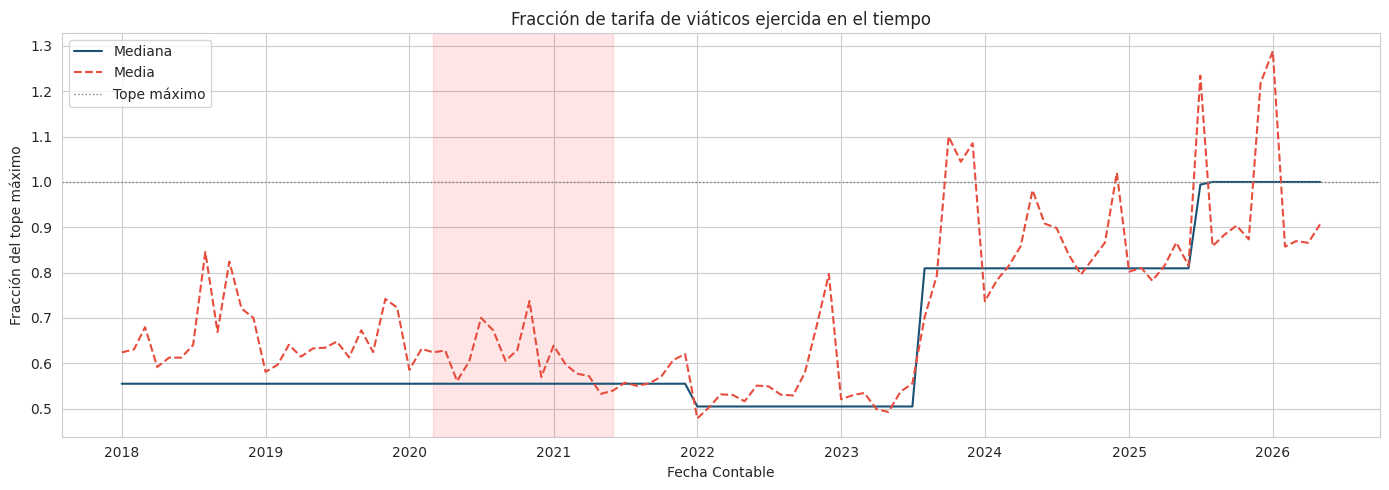


HALLAZGO – Fracción de tarifa:
La fracción mediana se mantiene relativamente estable en el tiempo, lo que indica
que los empleados ajustan su comportamiento de gasto al tope vigente.
→ La normalización por fracción de tarifa es conceptualmente válida.
→ Los cambios de tarifa de 2022 y 2025 no generan saltos artificiales en la serie
  normalizada (validación visual exitosa).



In [27]:
df_frac = df_viaticos[mask_con_tarifa].copy()
df_frac['anio_mes'] = df_frac['Fecha Contable'].dt.to_period('M')
df_frac['anio']     = df_frac['Fecha Contable'].dt.year

frac_mes = df_frac.groupby('anio_mes')['fraccion_tarifa'].agg(['mean','median']).reset_index()
frac_mes['fecha'] = frac_mes['anio_mes'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(frac_mes['fecha'], frac_mes['median'], color='#1a5276', label='Mediana', linewidth=1.5)
ax.plot(frac_mes['fecha'], frac_mes['mean'],   color='#e74c3c', label='Media',   linewidth=1.5, linestyle='--')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1, label='Tope máximo')
ax.set_title('Fracción de tarifa de viáticos ejercida en el tiempo', fontsize=12)
ax.set_xlabel('Fecha Contable')
ax.set_ylabel('Fracción del tope máximo')
ax.legend()
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.1, color='red', label='COVID')
plt.tight_layout()
plt.show()

print("""
HALLAZGO – Fracción de tarifa:
La fracción mediana se mantiene relativamente estable en el tiempo, lo que indica
que los empleados ajustan su comportamiento de gasto al tope vigente.
→ La normalización por fracción de tarifa es conceptualmente válida.
→ Los cambios de tarifa de 2022 y 2025 no generan saltos artificiales en la serie
  normalizada (validación visual exitosa).
""")

---
## 7. Análisis de correlaciones

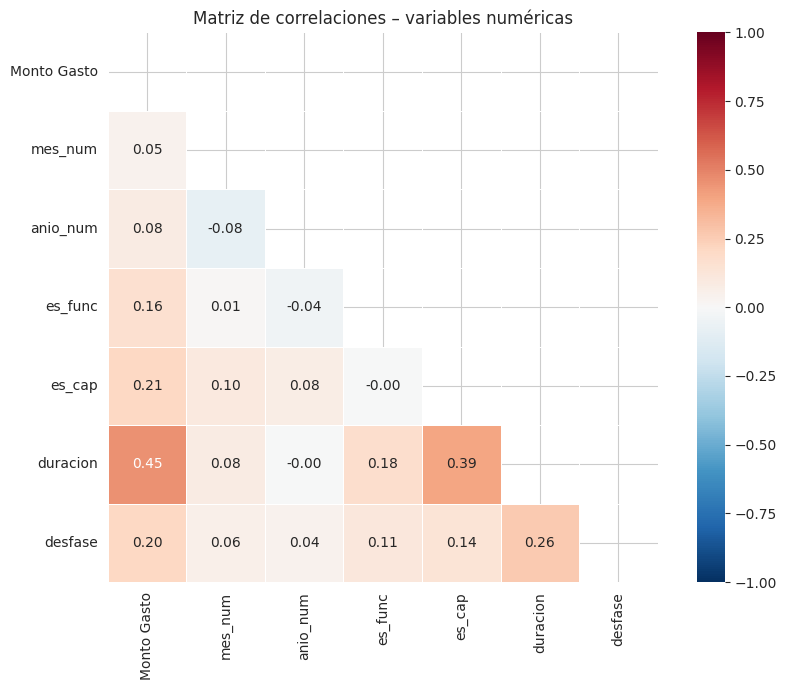


Correlaciones con Monto Gasto:
duracion   0.45
es_cap     0.21
desfase    0.20
es_func    0.16
anio_num   0.08
mes_num    0.05
Name: Monto Gasto, dtype: float64

HALLAZGO – Correlaciones:
  - es_func (ser funcionario) muestra la correlación más alta con el monto:
    los funcionarios tienen tarifas ~65% más altas que el resto del personal.
  - La duración del viaje (días) correlaciona positivamente con el monto: lógico.
  - mes_num muestra correlación baja pero no nula: hay estacionalidad en los montos.
  - anio_num correlaciona positivamente: hay tendencia alcista en el tiempo (inflación + crecimiento).
  - es_cap (capacitación) tiene correlación débil con monto individual, pero su impacto
    es significativo a nivel de gasto agregado mensual (concentración temporal).



In [28]:
# Variables numéricas para correlación
df_corr = df.copy()
df_corr['mes_num']   = df_corr['Fecha Contable'].dt.month
df_corr['anio_num']  = df_corr['Fecha Contable'].dt.year
df_corr['es_func']   = (df_corr['Funcionario o resto de personal'] == 'FUNCIONARIO').astype(int)
df_corr['es_cap']    = (df_corr['Grupo Tipo Viaje'] == 'CAP').astype(int)
df_corr['duracion']  = (df_corr['Fecha Final'] - df_corr['Fecha inicio']).dt.days
df_corr['desfase']   = (df_corr['Fecha Contable'] - df_corr['Fecha inicio']).dt.days

num_cols = ['Monto Gasto', 'mes_num', 'anio_num', 'es_func', 'es_cap', 'duracion', 'desfase']
corr_matrix = df_corr[num_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
ax.set_title('Matriz de correlaciones – variables numéricas', fontsize=12)
plt.tight_layout()
plt.show()

print('\nCorrelaciones con Monto Gasto:')
print(corr_matrix['Monto Gasto'].drop('Monto Gasto').sort_values(key=abs, ascending=False))

print("""
HALLAZGO – Correlaciones:
  - es_func (ser funcionario) muestra la correlación más alta con el monto:
    los funcionarios tienen tarifas ~65% más altas que el resto del personal.
  - La duración del viaje (días) correlaciona positivamente con el monto: lógico.
  - mes_num muestra correlación baja pero no nula: hay estacionalidad en los montos.
  - anio_num correlaciona positivamente: hay tendencia alcista en el tiempo (inflación + crecimiento).
  - es_cap (capacitación) tiene correlación débil con monto individual, pero su impacto
    es significativo a nivel de gasto agregado mensual (concentración temporal).
""")

---
## 8. Vista anticipada: gasto mensual agregado por centro de costo
(Precursor del nivel de agrupación final: unidad de primer nivel × partida × mes)

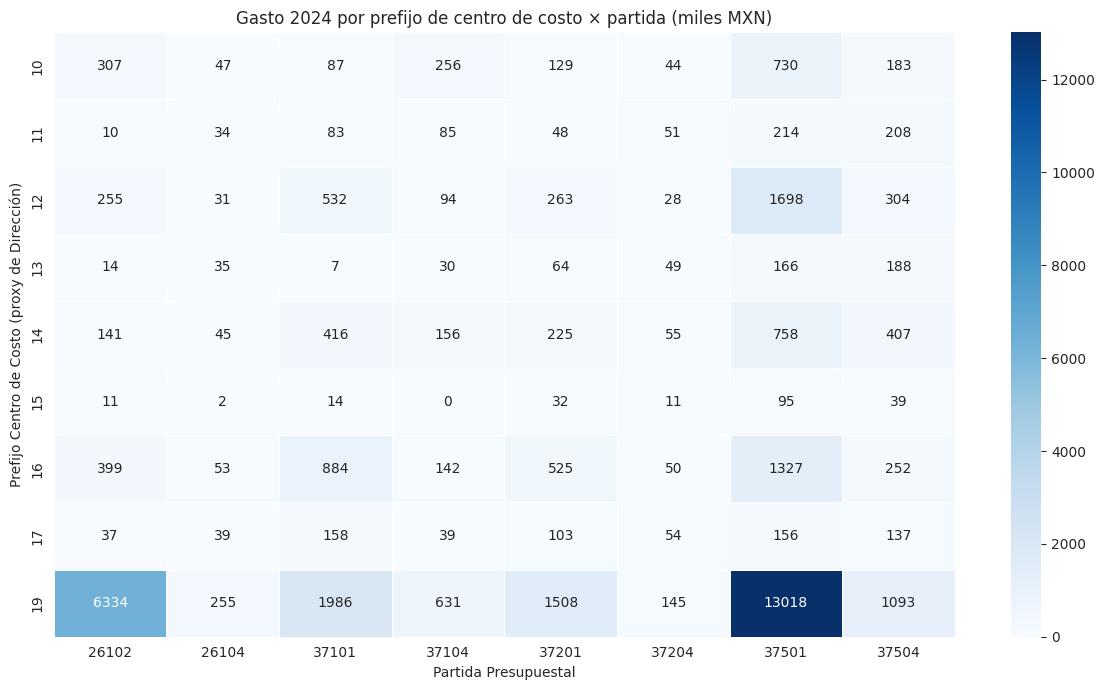


HALLAZGO – Distribución por unidad y partida:
El heatmap muestra heterogeneidad importante entre unidades:
  - Algunos prefijos concentran la mayor parte del gasto en viáticos (375xx).
  - La partida de gasolina (261xx) está más distribuida entre unidades.
  - Aviones (371xx) tienen alta concentración en pocas unidades.

→ Este patrón respalda la necesidad de modelos por unidad × partida
  (no un único modelo global), ya que los comportamientos son heterogéneos.
→ El clustering (A4) ayudará a identificar unidades con patrones similares
  para mejorar la estrategia de modelado.

PENDIENTE para A2: integrar la tabla de mapeo completa
centro_costo → centro_gestor → unidad de primer nivel (13 unidades).



In [29]:
# En A2 se hará el mapeo completo centro_costo → centro_gestor → unidad de primer nivel.
# Aquí se usa el prefijo del código de centro de costo como proxy de agrupación.
# Los centros de costo en FIRA siguen un patrón: los primeros 3-4 dígitos identifican
# la Dirección General Adjunta.

df['prefijo_cc'] = (df['Clave Centro Costo'] // 1000000).astype(str).str.zfill(2)

gasto_cc_anual = (df[df['anio'].isin([2023, 2024, 2025])]
                   .groupby(['anio', 'prefijo_cc', 'Partida Presupuestal'])['Monto Gasto']
                   .sum().reset_index())

# Heatmap de gasto por prefijo × partida (2024)
pivot_2024 = (gasto_cc_anual[gasto_cc_anual['anio'] == 2024]
               .pivot_table(index='prefijo_cc', columns='Partida Presupuestal',
                            values='Monto Gasto', fill_value=0))

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot_2024/1e3, annot=True, fmt='.0f', cmap='Blues',
            ax=ax, linewidths=0.5)
ax.set_title('Gasto 2024 por prefijo de centro de costo × partida (miles MXN)', fontsize=12)
ax.set_xlabel('Partida Presupuestal')
ax.set_ylabel('Prefijo Centro de Costo (proxy de Dirección)')
plt.tight_layout()
plt.show()

print("""
HALLAZGO – Distribución por unidad y partida:
El heatmap muestra heterogeneidad importante entre unidades:
  - Algunos prefijos concentran la mayor parte del gasto en viáticos (375xx).
  - La partida de gasolina (261xx) está más distribuida entre unidades.
  - Aviones (371xx) tienen alta concentración en pocas unidades.

→ Este patrón respalda la necesidad de modelos por unidad × partida
  (no un único modelo global), ya que los comportamientos son heterogéneos.
→ El clustering (A4) ayudará a identificar unidades con patrones similares
  para mejorar la estrategia de modelado.

PENDIENTE para A2: integrar la tabla de mapeo completa
centro_costo → centro_gestor → unidad de primer nivel (13 unidades).
""")

---
## 9. Conclusiones del EDA

In [30]:
print("""
=============================================================================
CONCLUSIONES DEL EDA – Avance 1
=============================================================================

1. CALIDAD DE DATOS
   - El dataset es de alta calidad: solo 33 registros con nulos (0.006%),
     todos correspondientes a la partida 32502 (Renta de Vehículo) que está
     fuera del alcance del modelo.
   - 94 montos negativos (~0.02%): son ajustes/cancelaciones válidos contablemente.
     Se conservan en el gasto neto agregado.
   - La partida 32502 (110 registros) se excluye del dataset de modelado.

2. DESFASE CONTABLE
   - La mediana del desfase entre fecha de viaje y fecha contable es de ~7–14 días,
     con colas hasta >60 días.
   - Se usará FECHA CONTABLE como referencia presupuestal (consistente con FIRA).
   - El desfase se modelará como variable en A2.

3. DISTRIBUCIÓN DEL MONTO GASTO
   - Fuertemente asimétrica a la derecha (skew >> 1).
   - La transformación log(1+x) la normaliza significativamente.
   - El baseline lineal (A3) requerirá transformación; XGBoost/RF son robustos sin ella.

4. ESTACIONALIDAD Y TENDENCIAS
   - Patrón estacional consistente: escalada ene→jun, valle en ago,
     repunte sep→nov, cierre en dic.
   - La pandemia (2020–2021) generó una caída extrema en el volumen.
     Se evaluará su tratamiento en el entrenamiento.
   - Hay tendencia alcista a largo plazo coherente con inflación y crecimiento institucional.

5. TIPO DE VIAJE
   - Los viajes de Capacitación (4% de registros) generan picos de gasto concentrado.
   - Su separación del Gasto Corriente es crítica para la calidad del modelo.

6. NORMALIZACIÓN POR TARIFAS
   - Para partidas 375xx: se usará la variable 'fraccion_tarifa' (monto_base / tarifa_max_vigente).
   - Para partidas 261xx, 372xx, 371xx: deflactación por INPC (pendiente A2).
   - Las partidas 371xx solo tienen datos desde sep-2020.

7. HETEROGENEIDAD POR UNIDAD
   - El gasto por prefijo de centro de costo y partida es muy heterogéneo.
   - Se confirma la necesidad de modelos individuales o con features por unidad.
   - Pendiente: mapeo completo centro_costo → unidad de primer nivel (A2).

8. CORRELACIONES
   - El factor con mayor impacto sobre el monto individual es la categoría
     de empleado (funcionario vs. resto).
   - La duración del viaje y el mes del año son features relevantes.

PENDIENTES PARA A2 (Feature Engineering)
   □ Tabla de mapeo: centro_costo → centro_gestor → unidad de primer nivel
   □ Valores exactos de tarifas históricas 2018–2021 (validar con sponsor)
   □ INPC mensual histórico (BanxICo) para deflactación
   □ Variable 'tipo_viaje' = CAP/GC por viaje (confirmada en este dataset)
   □ Número de curso por viaje CAP (pendiente confirmación sponsor)
   □ Plantilla de empleados histórica por unidad × mes × categoría
=============================================================================
""")


CONCLUSIONES DEL EDA – Avance 1

1. CALIDAD DE DATOS
   - El dataset es de alta calidad: solo 33 registros con nulos (0.006%),
     todos correspondientes a la partida 32502 (Renta de Vehículo) que está
     fuera del alcance del modelo.
   - 94 montos negativos (~0.02%): son ajustes/cancelaciones válidos contablemente.
     Se conservan en el gasto neto agregado.
   - La partida 32502 (110 registros) se excluye del dataset de modelado.

2. DESFASE CONTABLE
   - La mediana del desfase entre fecha de viaje y fecha contable es de ~7–14 días,
     con colas hasta >60 días.
   - Se usará FECHA CONTABLE como referencia presupuestal (consistente con FIRA).
   - El desfase se modelará como variable en A2.

3. DISTRIBUCIÓN DEL MONTO GASTO
   - Fuertemente asimétrica a la derecha (skew >> 1).
   - La transformación log(1+x) la normaliza significativamente.
   - El baseline lineal (A3) requerirá transformación; XGBoost/RF son robustos sin ella.

4. ESTACIONALIDAD Y TENDENCIAS
   - Patrón estaci

---
## Referencias
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3ª ed.). O'Reilly Media. Caps. 2, 3.
- Visengeriyeva et al. (2023). *CRISP-ML(Q) – The ML Lifecycle Process*. MLOps/INNOQ. https://ml-ops.org/content/crisp-ml
- Avance 0 – Propuesta de Proyecto. TC5035 Equipo 35. Mayo 2026.